📂 Loading Data...

📊 60-Minute Benchmark LEAGUE TABLE:
              Model   RMSE    MAE    R2  Imp (%)
   Physics GP (RBF)  2.625  1.646 1.000   95.814
Physics GP (Matern)  2.741  1.939 1.000   95.629
         LSTM (CSI)  3.369  2.380 1.000   94.627
        Baseline GP  7.310  5.847 0.998   88.344
         LSTM (Raw) 11.748  9.717 0.995   81.266
  Smart Persistence 62.710 37.308 0.861    0.000

📊 5-Minute Benchmark LEAGUE TABLE:
              Model   RMSE    MAE    R2  Imp (%)
   Physics GP (RBF)  0.314  0.227 1.000   99.235
         LSTM (CSI)  0.589  0.420 1.000   98.563
Physics GP (Matern)  0.980  0.828 1.000   97.610
        Baseline GP  8.178  6.338 0.998   80.047
         LSTM (Raw) 10.431  8.488 0.997   74.551
  Smart Persistence 40.987 19.582 0.947    0.000
📸 Saved Figure 1 (Ramp Event)
📸 Saved Figure 2 (Uncertainty Comparison)
📸 Saved Figure 3 (Scatter Plots)


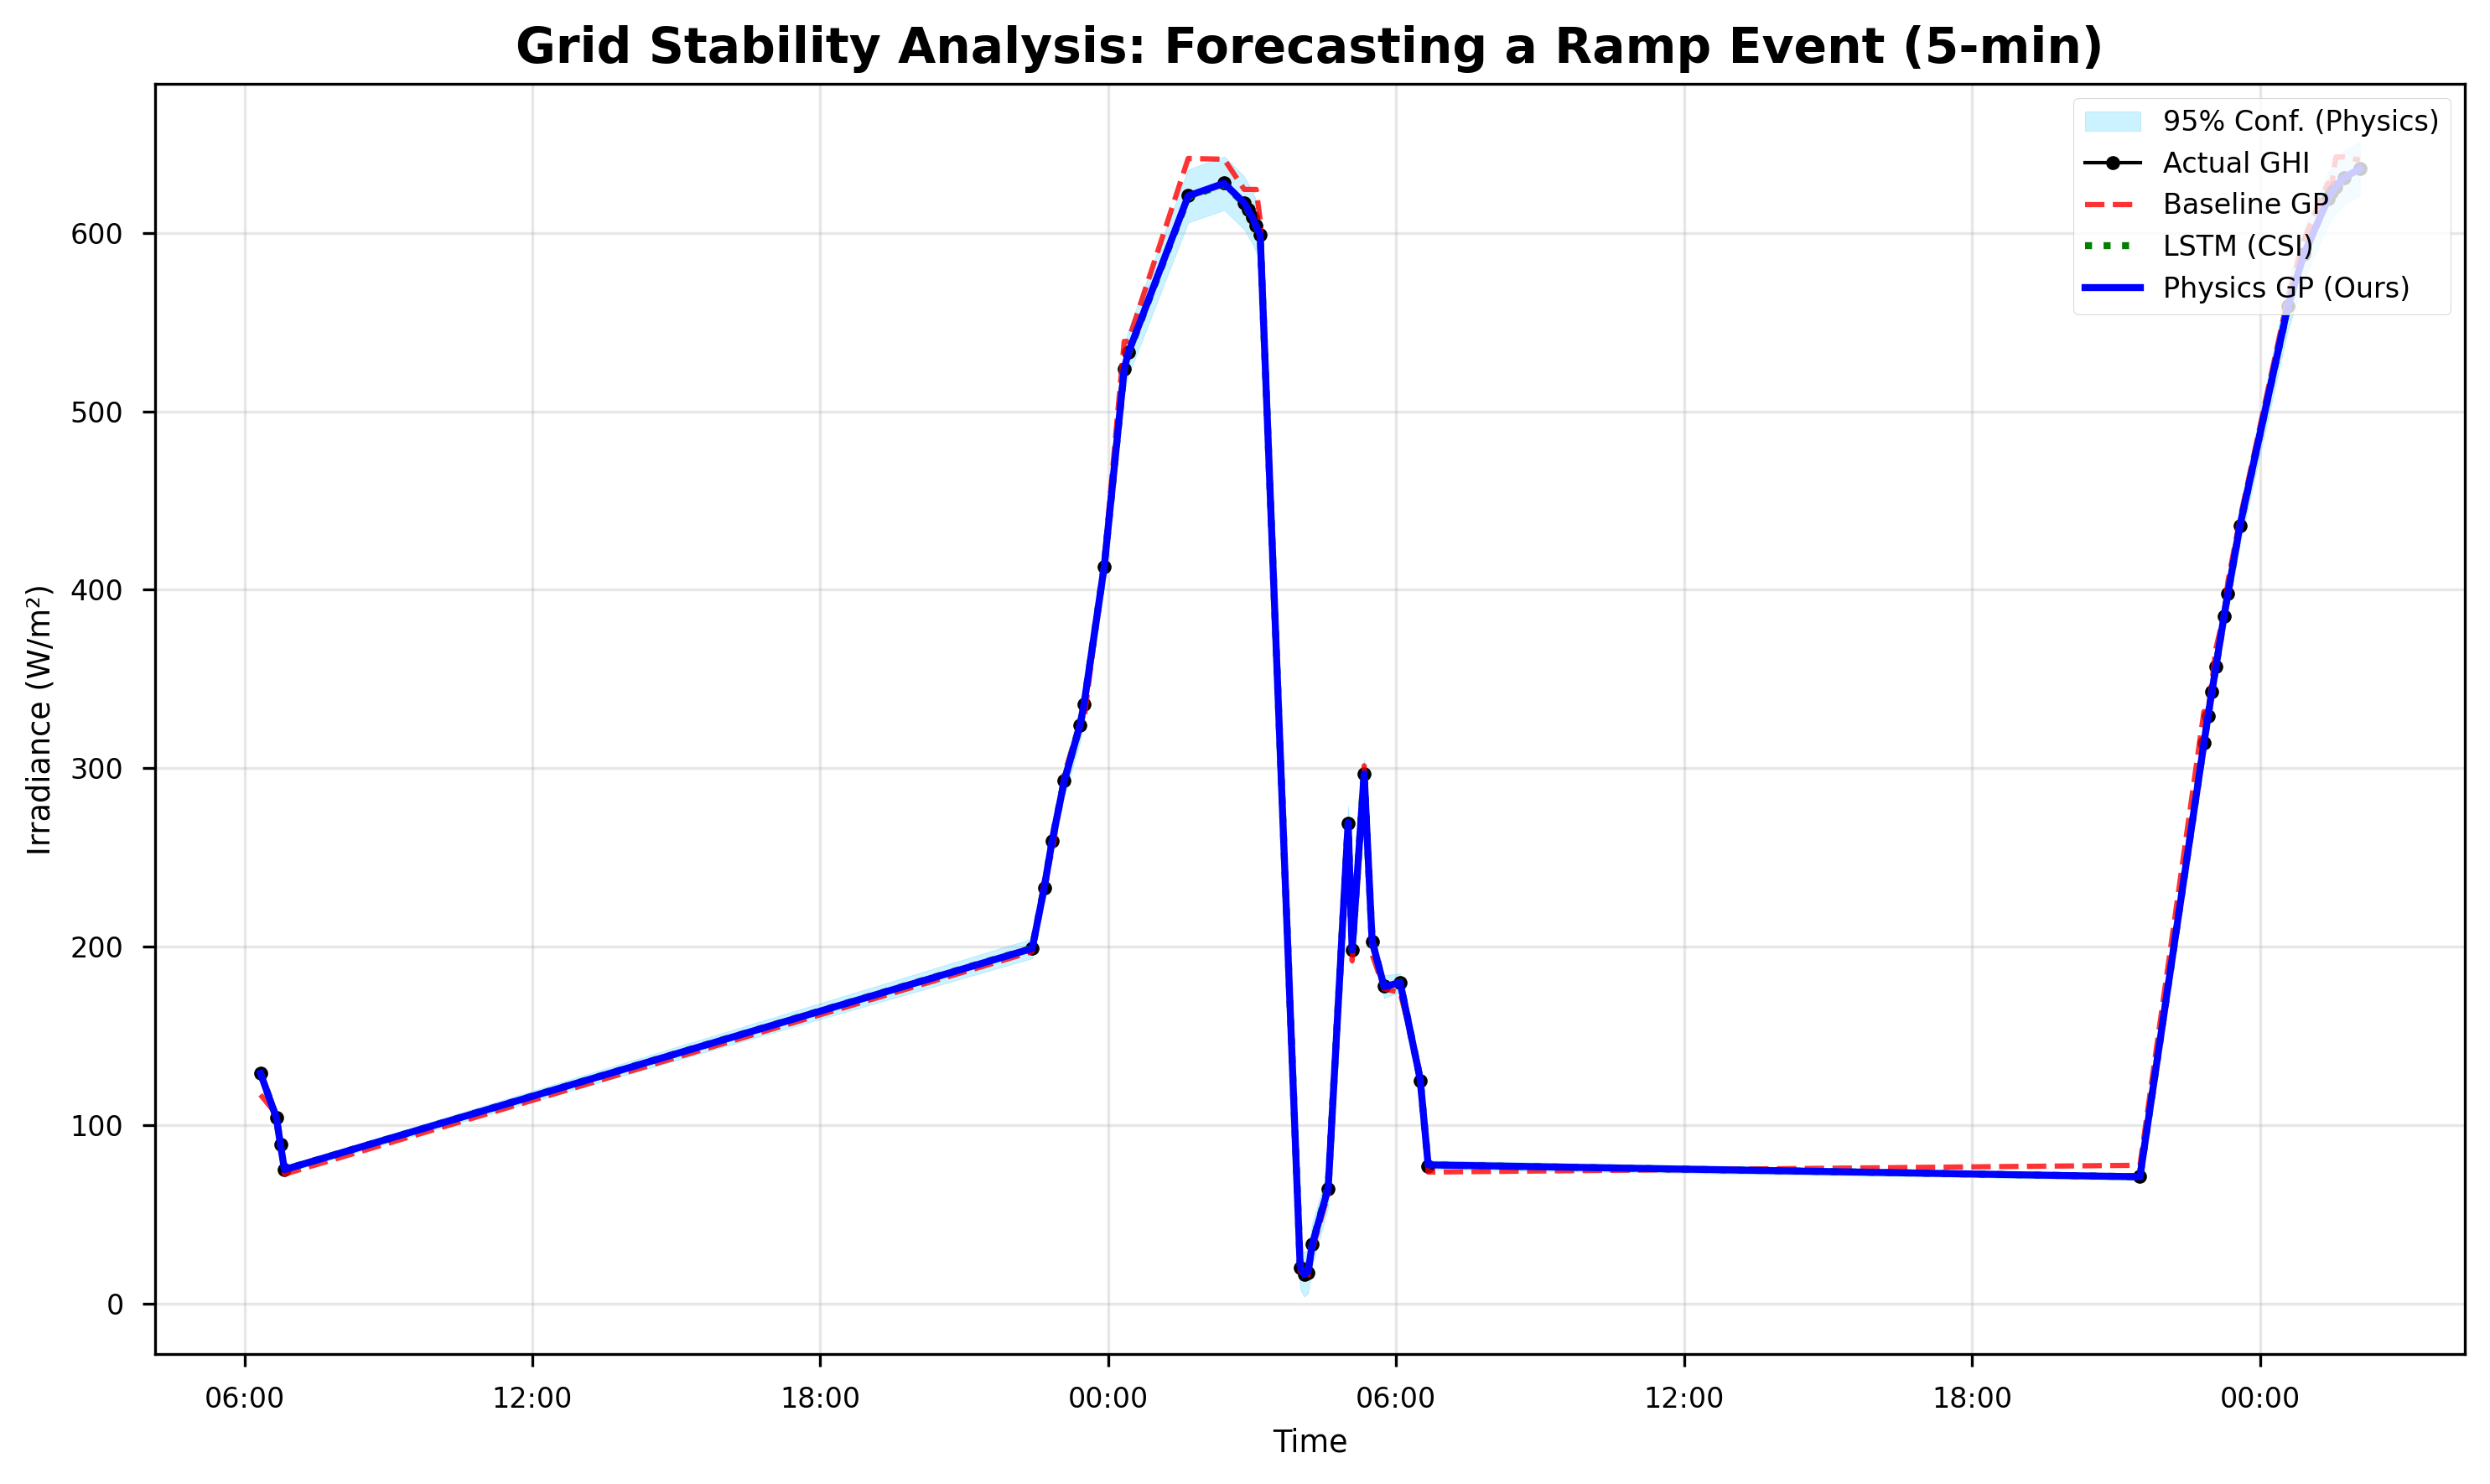

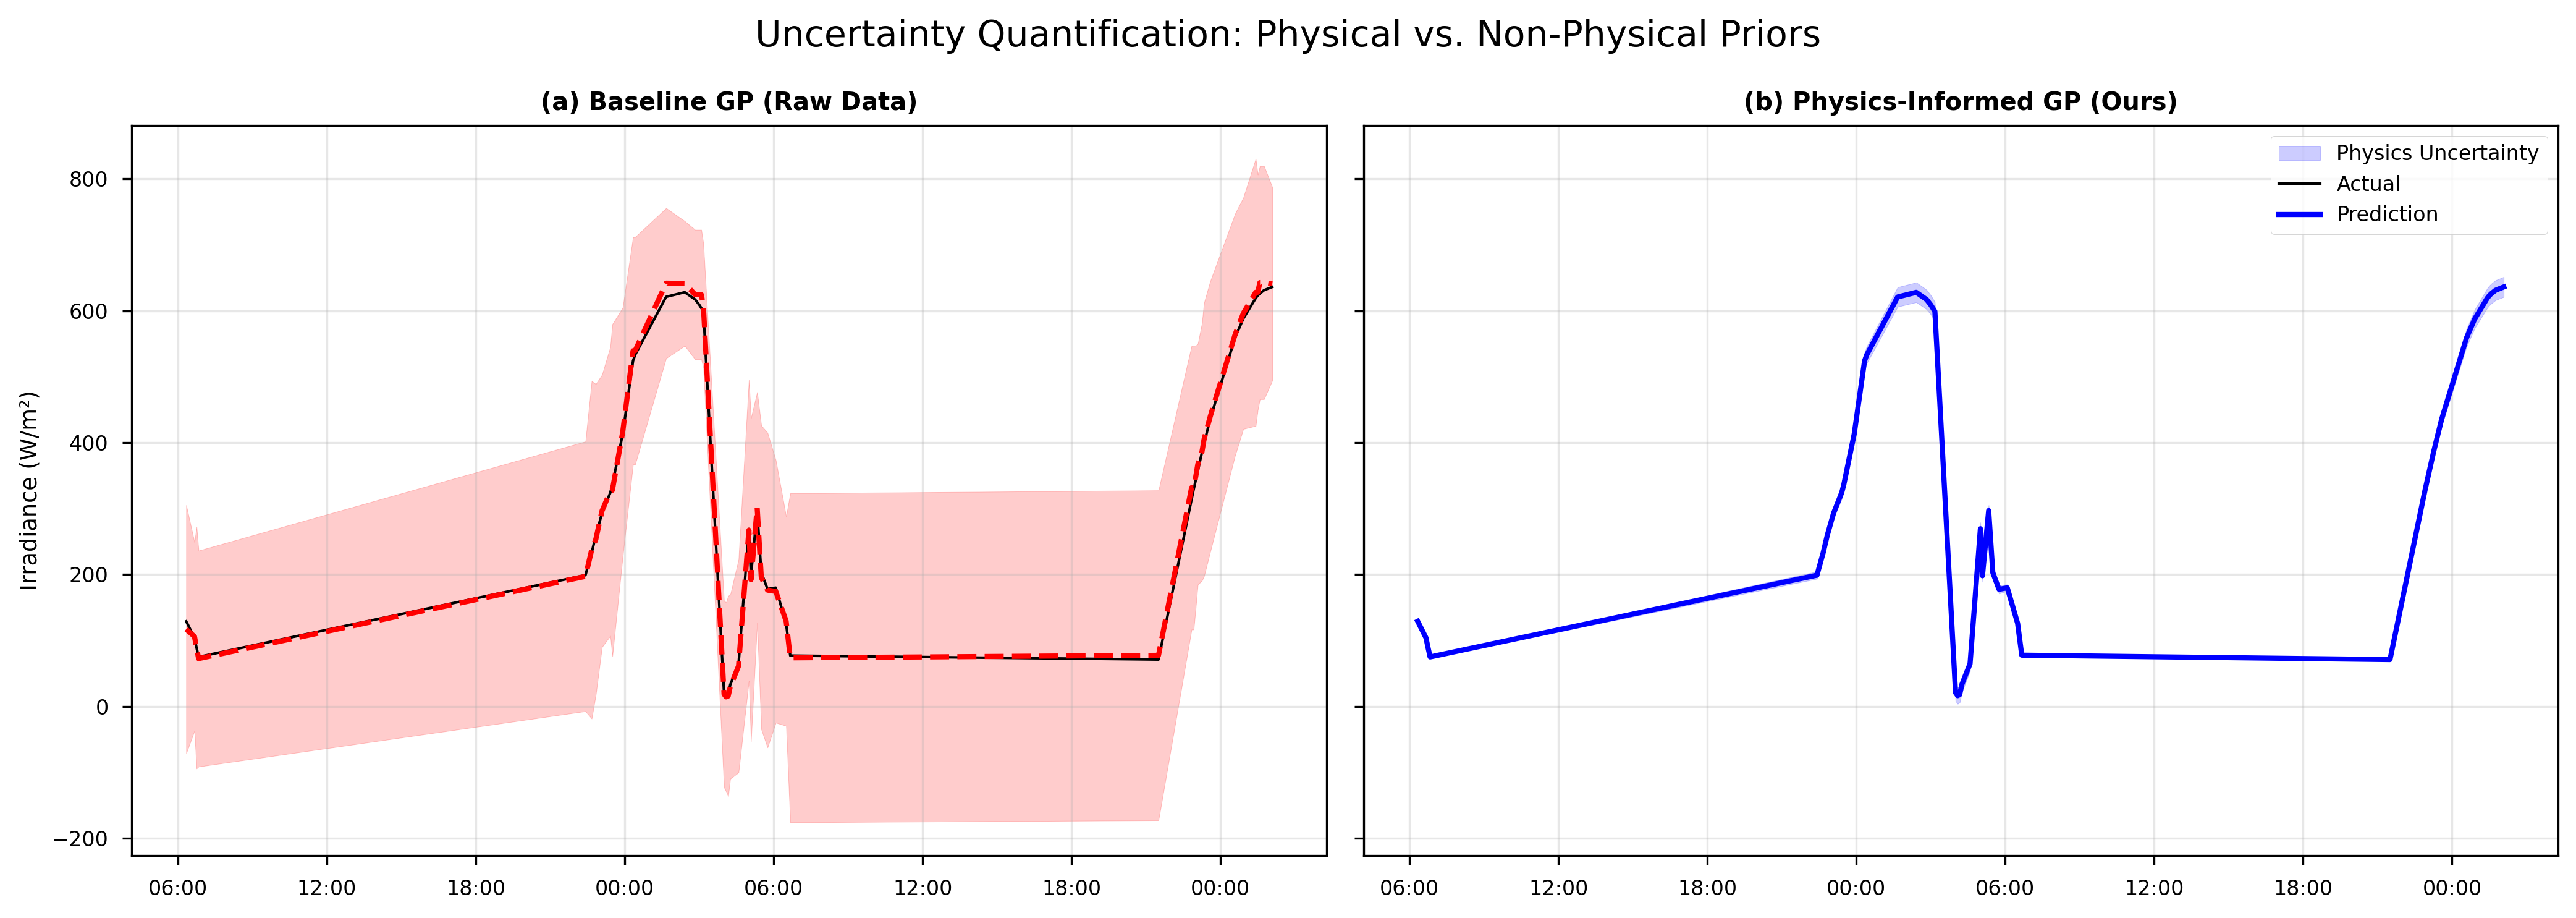

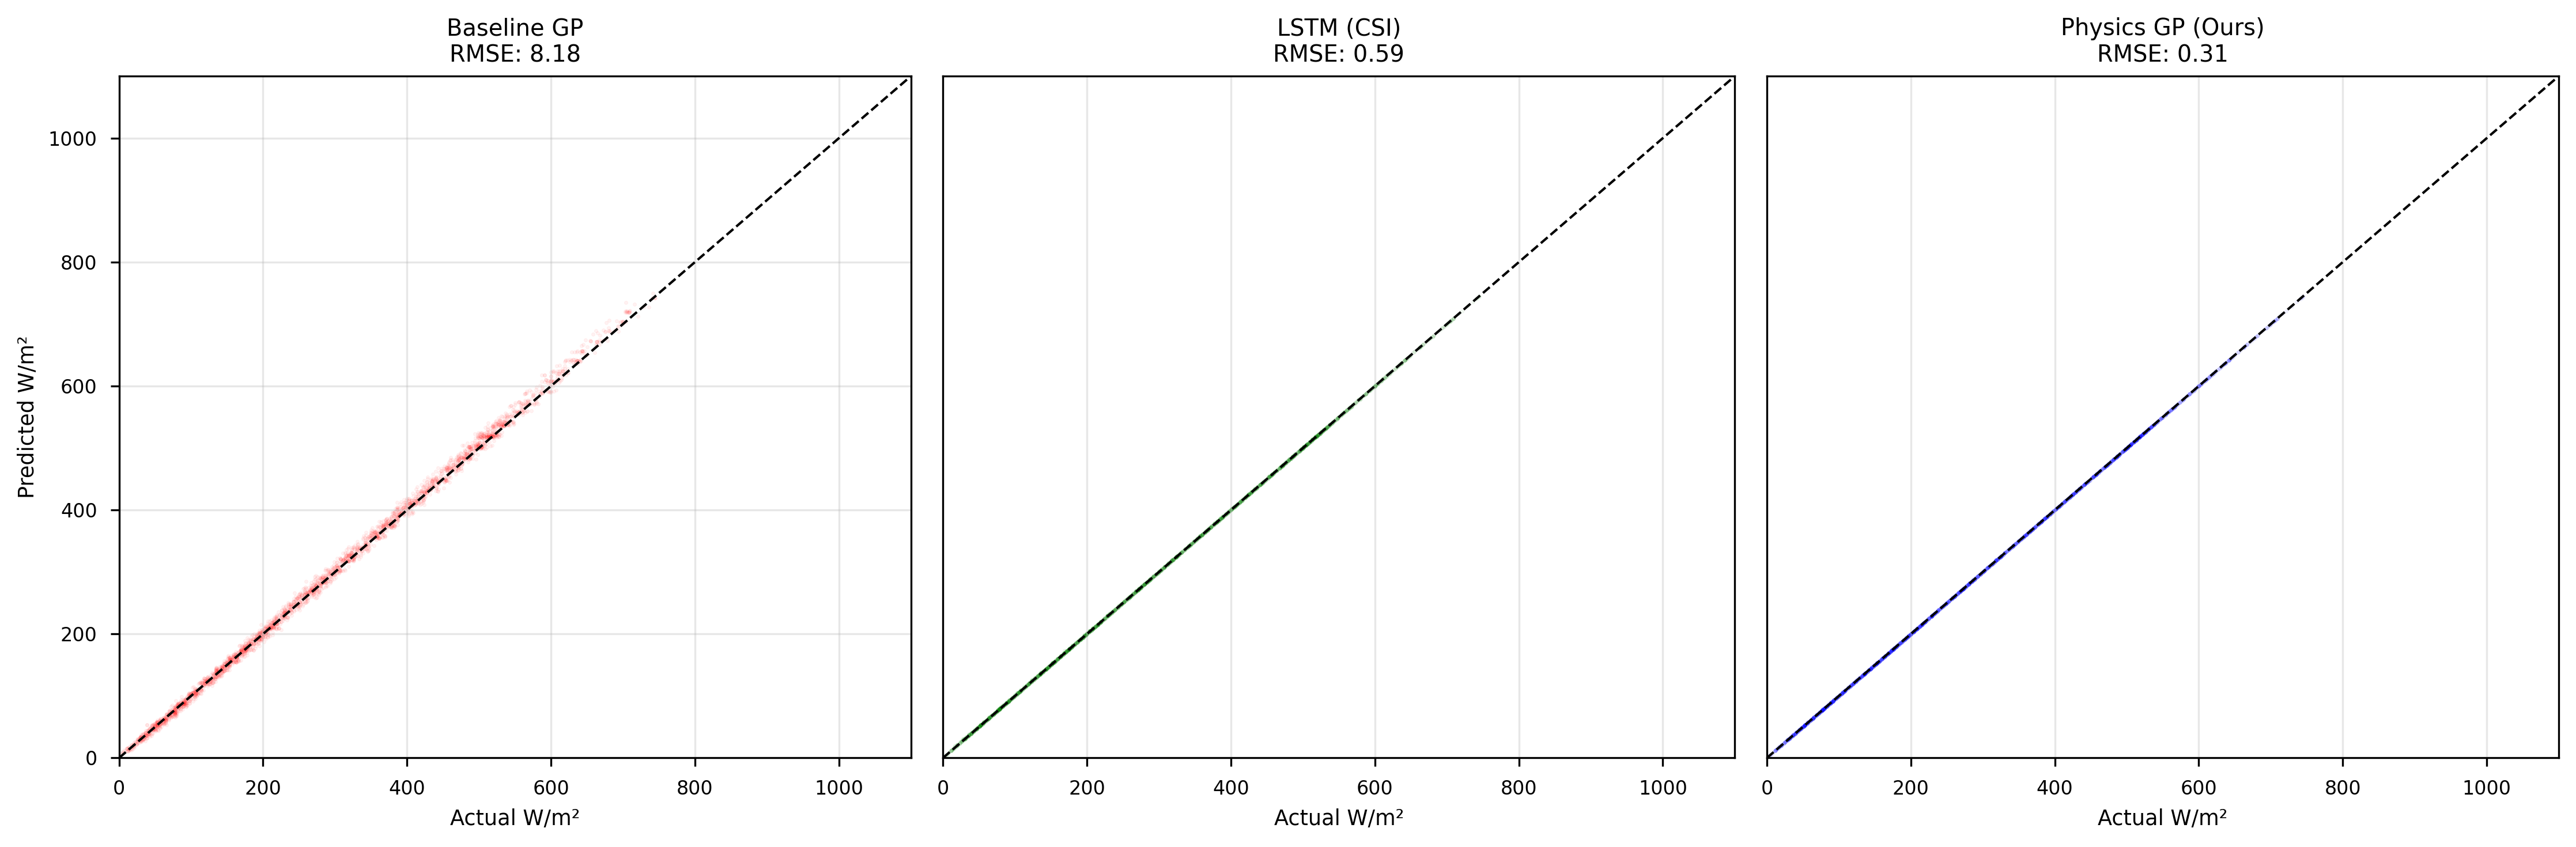

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import os
import seaborn as sns

# CONFIGURATION
plt.style.use('seaborn-v0_8-paper') # Professional style
os.makedirs("paper_plots", exist_ok=True)

# LOAD DATA
print("📂 Loading Data...")
try:
    df_5 = pd.read_csv("results/5min_all_predictions.csv", parse_dates=['Time'])
    df_60 = pd.read_csv("results/60min_all_predictions.csv", parse_dates=['Time'])
except FileNotFoundError:
    print("❌ Error: CSV files not found. Make sure they are in this folder.")
    exit()

# =============================================================================
# PART 1: GENERATE TABLES
# =============================================================================
def generate_table(df, name):
    models = [
        ('Smart Persistence', 'Smart_Persistence'),
        ('Baseline GP', 'Pred_Baseline_Raw'),
        ('LSTM (Raw)', 'Pred_LSTM_Raw'),
        ('LSTM (CSI)', 'Pred_LSTM_CSI'),
        ('Physics GP (Matern)', 'Pred_Physics_Matern'),
        ('Physics GP (RBF)', 'Pred_Physics_RBF')
    ]
    
    results = []
    y_true = df['Actual_GHI']
    
    for label, col in models:
        # Handle potential NaNs
        mask = df[col].notna() & df['Actual_GHI'].notna()
        y_t = df.loc[mask, 'Actual_GHI']
        y_p = df.loc[mask, col]
        
        rmse = np.sqrt(mean_squared_error(y_t, y_p))
        r2 = r2_score(y_t, y_p)
        mae = mean_absolute_error(y_t, y_p)
        
        results.append({
            "Model": label,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })
    
    res_df = pd.DataFrame(results).sort_values("RMSE")
    
    # Calculate improvement vs Persistence
    base_rmse = res_df.loc[res_df['Model'] == 'Smart Persistence', 'RMSE'].values[0]
    res_df['Imp (%)'] = (1 - res_df['RMSE'] / base_rmse) * 100
    
    print(f"\n📊 {name} LEAGUE TABLE:")
    print(res_df.round(3).to_string(index=False))
    return res_df

res_60 = generate_table(df_60, "60-Minute Benchmark")
res_5 = generate_table(df_5, "5-Minute Benchmark")

# =============================================================================
# PART 2: Ramp Event
# =============================================================================
# Find a volatile window in the 5-min dataset
# We look for where the Rolling Standard Deviation is high
df_5['Rolling_Std'] = df_5['Actual_GHI'].rolling(12).std()
peak_idx = df_5['Rolling_Std'].idxmax()

# Create a 4-hour window around the peak volatility
window = 48 # 4 hours * 12 points/hr
start = max(0, peak_idx - 24)
end = min(len(df_5), peak_idx + 24)
subset = df_5.iloc[start:end]

plt.figure(figsize=(10, 6), dpi=300)

# Confidence Interval (Physics)
plt.fill_between(subset['Time'], subset['RBF_Lower_CI'], subset['RBF_Upper_CI'], 
                 color='deepskyblue', alpha=0.2, label='95% Conf. (Physics)')

# Lines
plt.plot(subset['Time'], subset['Actual_GHI'], 'k-o', markersize=4, lw=1, label='Actual GHI')
plt.plot(subset['Time'], subset['Pred_Baseline_Raw'], 'r--', lw=1.5, alpha=0.8, label='Baseline GP')
plt.plot(subset['Time'], subset['Pred_LSTM_CSI'], 'g:', lw=2, label='LSTM (CSI)')
plt.plot(subset['Time'], subset['Pred_Physics_RBF'], 'b-', lw=2, label='Physics GP (Ours)')

plt.title("Grid Stability Analysis: Forecasting a Ramp Event (5-min)", fontsize=14, fontweight='bold')
plt.ylabel("Irradiance (W/m²)")
plt.xlabel("Time")
plt.legend(loc='upper right', frameon=True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("paper_plots/Figure1_RampEvent.png")
print("📸 Saved Figure 1 (Ramp Event)")

# =============================================================================
# PART 3: CONFIDENCE INTERVAL COMPARISON (Physics vs Baseline)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300, sharey=True)

# Plot 1: Baseline
axes[0].fill_between(subset['Time'], subset['Baseline_Lower_CI'], subset['Baseline_Upper_CI'], 
                     color='red', alpha=0.2, label='Baseline Uncertainty')
axes[0].plot(subset['Time'], subset['Actual_GHI'], 'k-', lw=1)
axes[0].plot(subset['Time'], subset['Pred_Baseline_Raw'], 'r--', lw=2)
axes[0].set_title("(a) Baseline GP (Raw Data)", fontweight='bold')
axes[0].set_ylabel("Irradiance (W/m²)")
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Plot 2: Physics
axes[1].fill_between(subset['Time'], subset['RBF_Lower_CI'], subset['RBF_Upper_CI'], 
                     color='blue', alpha=0.2, label='Physics Uncertainty')
axes[1].plot(subset['Time'], subset['Actual_GHI'], 'k-', lw=1, label='Actual')
axes[1].plot(subset['Time'], subset['Pred_Physics_RBF'], 'b-', lw=2, label='Prediction')
axes[1].set_title("(b) Physics-Informed GP (Ours)", fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.suptitle("Uncertainty Quantification: Physical vs. Non-Physical Priors", fontsize=14)
plt.tight_layout()
plt.savefig("paper_plots/Figure2_Uncertainty_Comparison.png")
print("📸 Saved Figure 2 (Uncertainty Comparison)")

# =============================================================================
# PART 4: SCATTER PLOTS (Accuracy Check)
# =============================================================================
plt.figure(figsize=(15, 5), dpi=300)

limits = [0, 1100]

# Subplot 1: Baseline
plt.subplot(1, 3, 1)
plt.scatter(df_5['Actual_GHI'], df_5['Pred_Baseline_Raw'], alpha=0.05, s=2, c='red')
plt.plot(limits, limits, 'k--', lw=1)
plt.title(f"Baseline GP\nRMSE: {res_5.loc[res_5['Model']=='Baseline GP','RMSE'].values[0]:.2f}")
plt.xlabel("Actual W/m²"); plt.ylabel("Predicted W/m²")
plt.xlim(limits); plt.ylim(limits)
plt.grid(True, alpha=0.3)

# Subplot 2: LSTM
plt.subplot(1, 3, 2)
plt.scatter(df_5['Actual_GHI'], df_5['Pred_LSTM_CSI'], alpha=0.05, s=2, c='green')
plt.plot(limits, limits, 'k--', lw=1)
plt.title(f"LSTM (CSI)\nRMSE: {res_5.loc[res_5['Model']=='LSTM (CSI)','RMSE'].values[0]:.2f}")
plt.xlabel("Actual W/m²"); 
plt.xlim(limits); plt.ylim(limits)
plt.yticks([])
plt.grid(True, alpha=0.3)

# Subplot 3: Physics GP
plt.subplot(1, 3, 3)
plt.scatter(df_5['Actual_GHI'], df_5['Pred_Physics_RBF'], alpha=0.05, s=2, c='blue')
plt.plot(limits, limits, 'k--', lw=1)
plt.title(f"Physics GP (Ours)\nRMSE: {res_5.loc[res_5['Model']=='Physics GP (RBF)','RMSE'].values[0]:.2f}")
plt.xlabel("Actual W/m²"); 
plt.xlim(limits); plt.ylim(limits)
plt.yticks([])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("paper_plots/Figure3_Scatter.png")
print("📸 Saved Figure 3 (Scatter Plots)")

📸 Saved Corrected 2x2 Comparison Figure


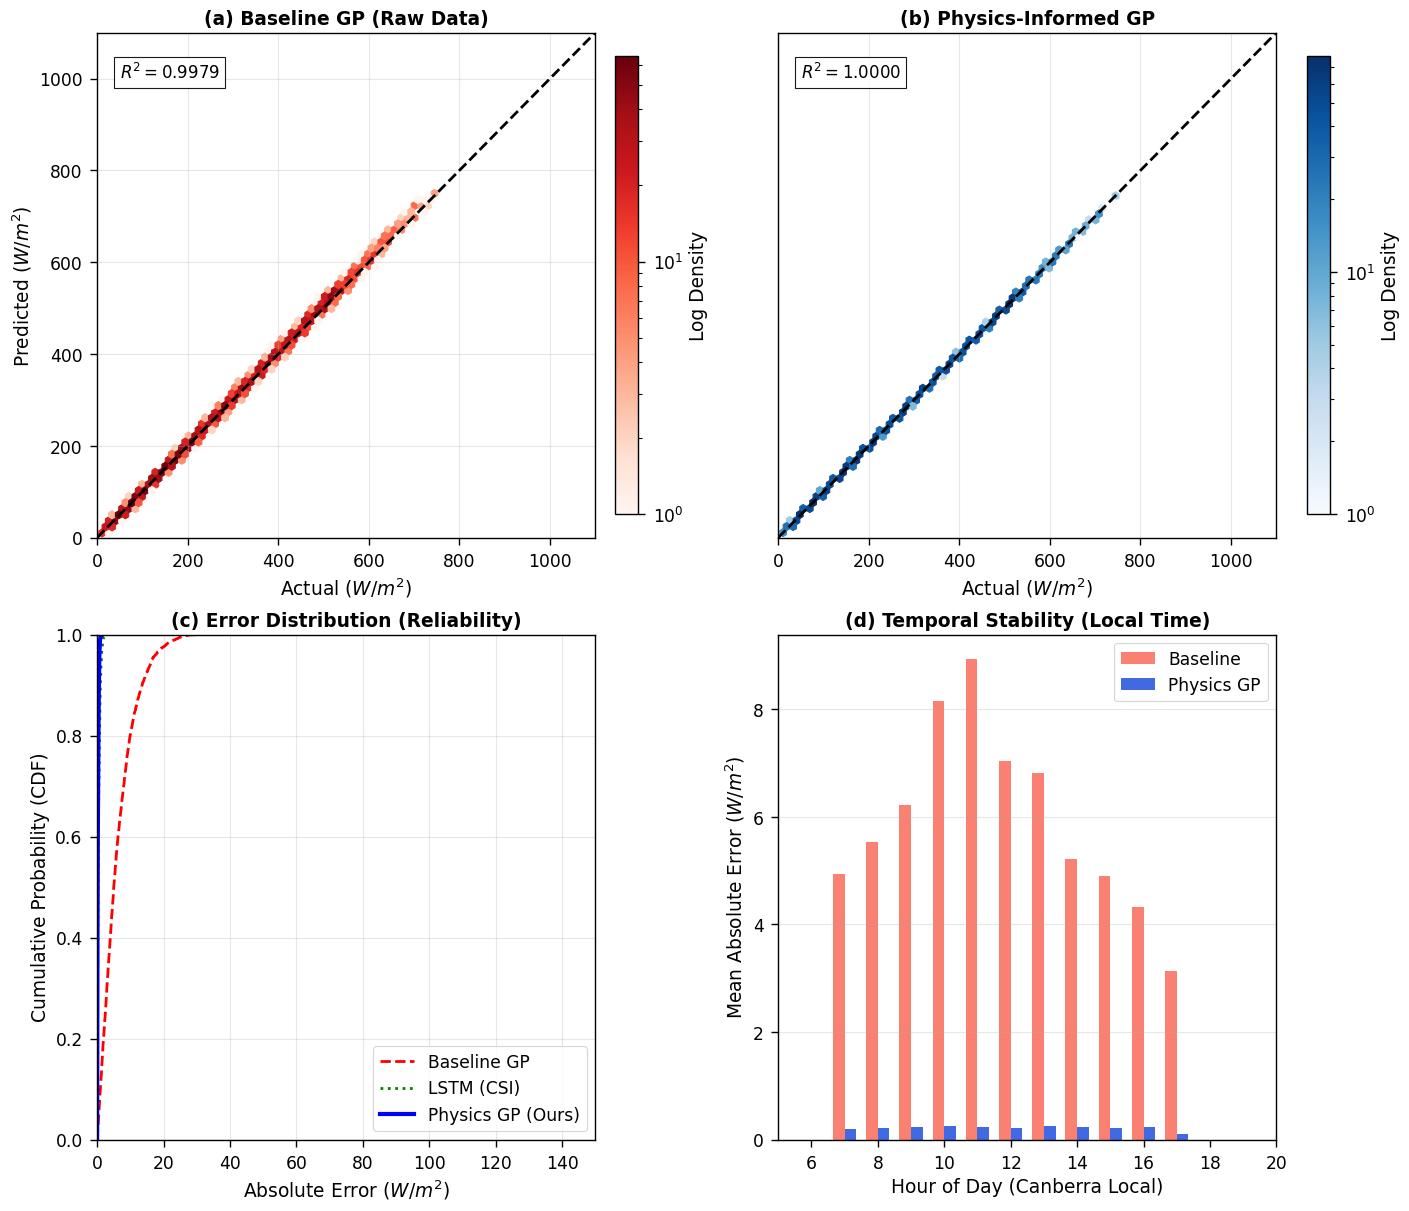

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# CONFIGURATION
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.4) 

# LOAD DATA
try:
    df = pd.read_csv("results/5min_all_predictions.csv", parse_dates=['Time'])
    # Filter for Scatter plots (Daylight only)
    df_day = df[df['Actual_GHI'] > 10].copy() 
    
    # Calculate Absolute Errors
    df['Err_Base'] = (df['Pred_Baseline_Raw'] - df['Actual_GHI']).abs()
    df['Err_Phys'] = (df['Pred_Physics_RBF'] - df['Actual_GHI']).abs()
    df['Err_LSTM'] = (df['Pred_LSTM_CSI'] - df['Actual_GHI']).abs()
except FileNotFoundError:
    print("❌ Error: '5min_all_predictions.csv' not found."); exit()

# =============================================================================
# 2x2 GRID LAYOUT
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
limits = [0, 1100]

# ---------------------------------------------------------
# 1. TOP LEFT: BASELINE SCATTER
# ---------------------------------------------------------
ax1 = axes[0, 0]
hb1 = ax1.hexbin(df_day['Actual_GHI'], df_day['Pred_Baseline_Raw'], 
                 gridsize=50, cmap='Reds', mincnt=1, bins='log')
ax1.plot(limits, limits, 'k--', lw=2)
r2_base = r2_score(df_day['Actual_GHI'], df_day['Pred_Baseline_Raw'])
ax1.text(50, 1000, f"$R^2 = {r2_base:.4f}$", fontsize=12, fontweight='bold', 
         bbox=dict(facecolor='white', alpha=0.9))

ax1.set_title("(a) Baseline GP (Raw Data)", fontweight='bold')
ax1.set_ylabel("Predicted ($W/m^2$)")
ax1.set_xlabel("Actual ($W/m^2$)")
ax1.set_xlim(limits); ax1.set_ylim(limits)
ax1.grid(True, alpha=0.3)
cb1 = fig.colorbar(hb1, ax=ax1, fraction=0.046, pad=0.04)
cb1.set_label('Log Density')

# ---------------------------------------------------------
# 2. TOP RIGHT: PHYSICS SCATTER
# ---------------------------------------------------------
ax2 = axes[0, 1]
hb2 = ax2.hexbin(df_day['Actual_GHI'], df_day['Pred_Physics_RBF'], 
                 gridsize=50, cmap='Blues', mincnt=1, bins='log')
ax2.plot(limits, limits, 'k--', lw=2)
r2_phys = r2_score(df_day['Actual_GHI'], df_day['Pred_Physics_RBF'])
ax2.text(50, 1000, f"$R^2 = {r2_phys:.4f}$", fontsize=12, fontweight='bold', 
         bbox=dict(facecolor='white', alpha=0.9))

ax2.set_title("(b) Physics-Informed GP", fontweight='bold')
ax2.set_xlabel("Actual ($W/m^2$)")
ax2.set_xlim(limits); ax2.set_ylim(limits)
ax2.set_yticks([]) 
ax2.grid(True, alpha=0.3)
cb2 = fig.colorbar(hb2, ax=ax2, fraction=0.046, pad=0.04)
cb2.set_label('Log Density')

# ---------------------------------------------------------
# 3. BOTTOM LEFT: CDF (Reliability)
# ---------------------------------------------------------
ax3 = axes[1, 0]
def get_cdf(data):
    sorted_data = np.sort(data)
    yvals = np.arange(len(sorted_data)) / float(len(sorted_data) - 1)
    return sorted_data, yvals

x_b, y_b = get_cdf(df['Err_Base'])
x_p, y_p = get_cdf(df['Err_Phys'])
x_l, y_l = get_cdf(df['Err_LSTM'])

ax3.plot(x_b, y_b, 'r--', lw=2, label='Baseline GP')
ax3.plot(x_l, y_l, 'g:', lw=2, label='LSTM (CSI)')
ax3.plot(x_p, y_p, 'b-', lw=3, label='Physics GP (Ours)')

ax3.set_xlim(0, 150); ax3.set_ylim(0, 1.0)
ax3.set_xlabel("Absolute Error ($W/m^2$)")
ax3.set_ylabel("Cumulative Probability (CDF)")
ax3.set_title("(c) Error Distribution (Reliability)", fontweight='bold')
ax3.legend(loc='lower right')
ax3.grid(True, alpha=0.3)

# ---------------------------------------------------------
# 4. BOTTOM RIGHT: HOURLY STABILITY (Fixed to Canberra Time)
# ---------------------------------------------------------
ax4 = axes[1, 1]

# TIMEZONE FIX: Canberra is UTC+10
# We add 10 hours to the UTC timestamp to align "Solar Noon" with 12:00
df['LocalTime'] = df['Time'] + pd.Timedelta(hours=10)
df['LocalHour'] = df['LocalTime'].dt.hour

# Group by LOCAL Hour
df_hourly = df.groupby('LocalHour')[['Err_Base', 'Err_Phys']].mean()

# Re-index 0-23
all_hours = np.arange(24)
df_hourly = df_hourly.reindex(all_hours, fill_value=0)

# Filter for Daylight (Local Time 06:00 - 20:00)
# This will show the "Middle of the Day" correctly
mask = (df_hourly.index >= 6) & (df_hourly.index <= 19)
df_plot = df_hourly[mask]

x = df_plot.index
width = 0.35

ax4.bar(x - width/2, df_plot['Err_Base'], width, label='Baseline', color='salmon')
ax4.bar(x + width/2, df_plot['Err_Phys'], width, label='Physics GP', color='royalblue')

ax4.set_title("(d) Temporal Stability (Local Time)", fontweight='bold')
ax4.set_xlabel("Hour of Day (Canberra Local)")
ax4.set_ylabel("Mean Absolute Error ($W/m^2$)")
ax4.set_xticks(np.arange(6, 21, 2)) # Label every 2 hours
ax4.set_xlim(5, 20) # Zoom in on the Day
ax4.legend()
ax4.grid(True, axis='y', alpha=0.3)

# SAVE
plt.savefig("paper_plots/Figure_Global_Comparison_2x2.png", dpi=300)
print("📸 Saved Corrected 2x2 Comparison Figure")
plt.show()

📸 Saved Figure_Performance_Comparison.png


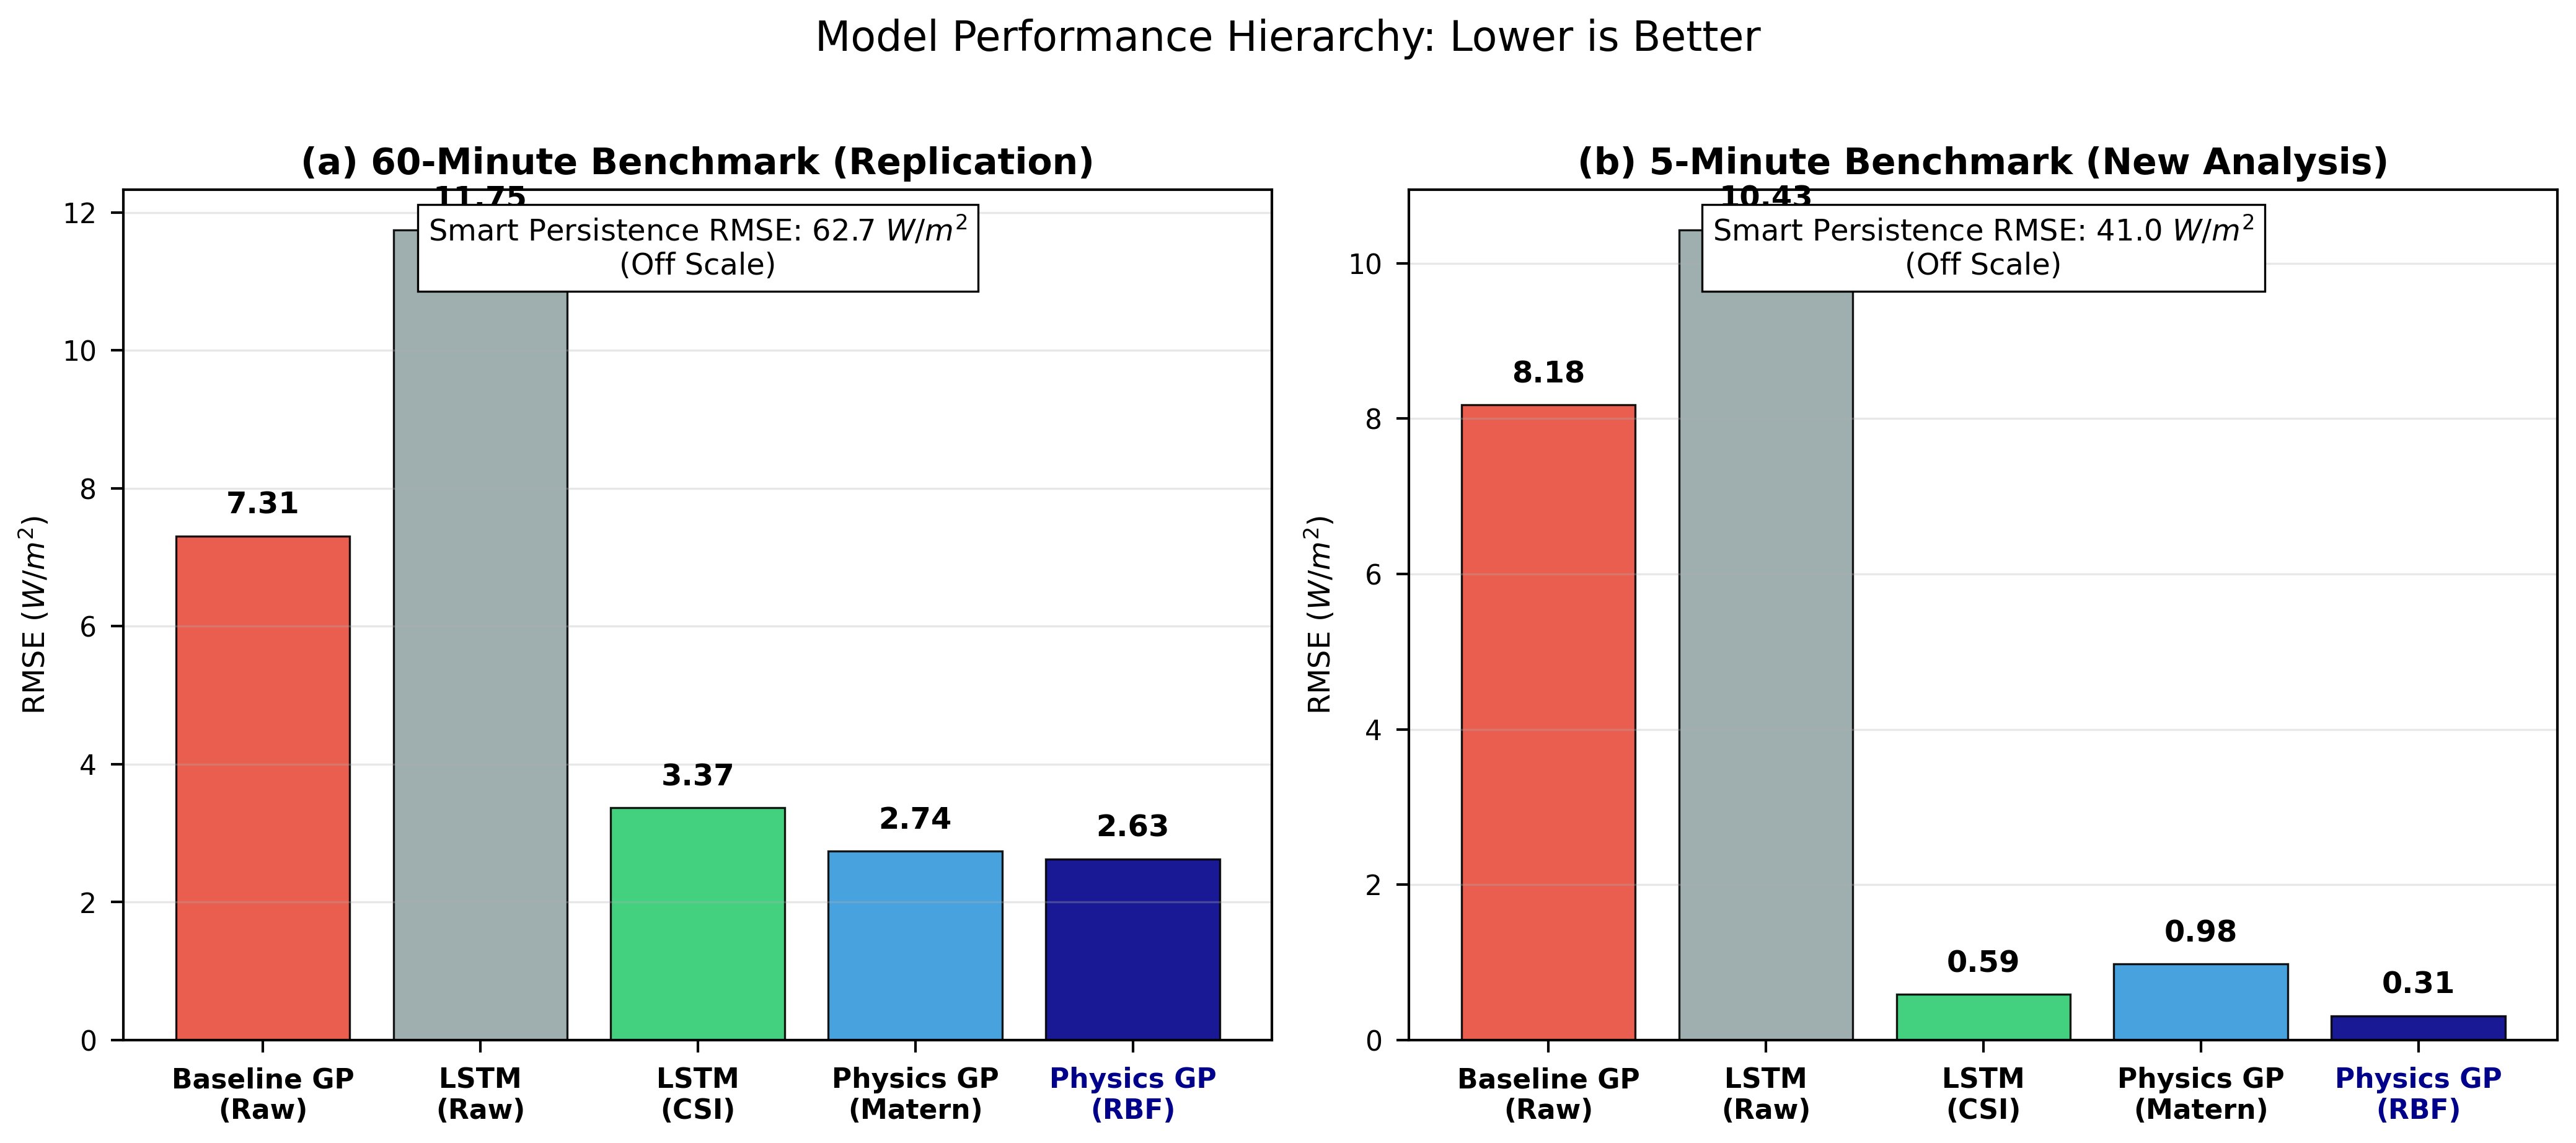

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# CONFIGURATION
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.2)

# LOAD DATA
try:
    df_5 = pd.read_csv("results/5min_all_predictions.csv")
    df_60 = pd.read_csv("results/60min_all_predictions.csv")
except FileNotFoundError:
    print("❌ Error: CSVs not found."); exit()

# DEFINITIONS
models = [
    ('Pred_Baseline_Raw', 'Baseline GP\n(Raw)', '#e74c3c'),       # Red
    ('Pred_LSTM_Raw', 'LSTM\n(Raw)', '#95a5a6'),                 # Gray
    ('Pred_LSTM_CSI', 'LSTM\n(CSI)', '#2ecc71'),                 # Green
    ('Pred_Physics_Matern', 'Physics GP\n(Matern)', '#3498db'),  # Light Blue
    ('Pred_Physics_RBF', 'Physics GP\n(RBF)', '#00008b')         # Dark Blue (Winner)
]

def get_rmses(df):
    scores = []
    # Calculate ML Models
    for col, label, color in models:
        # Filter NaNs just in case
        mask = df[col].notna() & df['Actual_GHI'].notna()
        rmse = np.sqrt(mean_squared_error(df.loc[mask, 'Actual_GHI'], df.loc[mask, col]))
        scores.append(rmse)
    
    # Calculate Persistence (The Ceiling)
    pers_mask = df['Smart_Persistence'].notna() & df['Actual_GHI'].notna()
    pers_rmse = np.sqrt(mean_squared_error(df.loc[pers_mask, 'Actual_GHI'], df.loc[pers_mask, 'Smart_Persistence']))
    
    return scores, pers_rmse

rmse_60, pers_60 = get_rmses(df_60)
rmse_5, pers_5 = get_rmses(df_5)

# =============================================================================
# PLOTTING
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

# --- HELPER FUNCTION TO DRAW BARS ---
def draw_subplot(ax, rmses, pers_score, title):
    labels = [m[1] for m in models]
    colors = [m[2] for m in models]
    x_pos = np.arange(len(labels))
    
    # Draw Bars
    bars = ax.bar(x_pos, rmses, color=colors, edgecolor='black', alpha=0.9)
    
    # Add Values on Top
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (max(rmses)*0.02),
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
    
    # Add Persistence Line (Benchmark)
    # We only show it if it fits reasonably, otherwise we annotate
    if pers_score < max(rmses) * 2: 
        ax.axhline(pers_score, color='black', linestyle='--', linewidth=2, label='Smart Persistence')
        ax.text(len(labels)-1, pers_score + (max(rmses)*0.02), f'Persistence: {pers_score:.1f}', 
                ha='right', va='bottom', style='italic')
    else:
        # If persistence is huge (like in 5-min), add a text box instead
        ax.text(0.5, 0.9, f"Smart Persistence RMSE: {pers_score:.1f} $W/m^2$\n(Off Scale)", 
                transform=ax.transAxes, ha='center', bbox=dict(facecolor='white', edgecolor='black'))

    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=0, fontweight='bold')
    ax.set_ylabel("RMSE ($W/m^2$)")
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
    
    # Highlight the Winner
    winner_idx = np.argmin(rmses)
    ax.get_xticklabels()[winner_idx].set_color('#00008b')

# --- DRAW PANELS ---
draw_subplot(axes[0], rmse_60, pers_60, "(a) 60-Minute Benchmark (Replication)")
draw_subplot(axes[1], rmse_5, pers_5, "(b) 5-Minute Benchmark (New Analysis)")

plt.suptitle("Model Performance Hierarchy: Lower is Better", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("paper_plots/Figure_Performance_Comparison.png", bbox_inches='tight')
print("📸 Saved Figure_Performance_Comparison.png")
plt.show()

📸 Saved paper_plots/Figure_Forecast_Horizon_60min.png


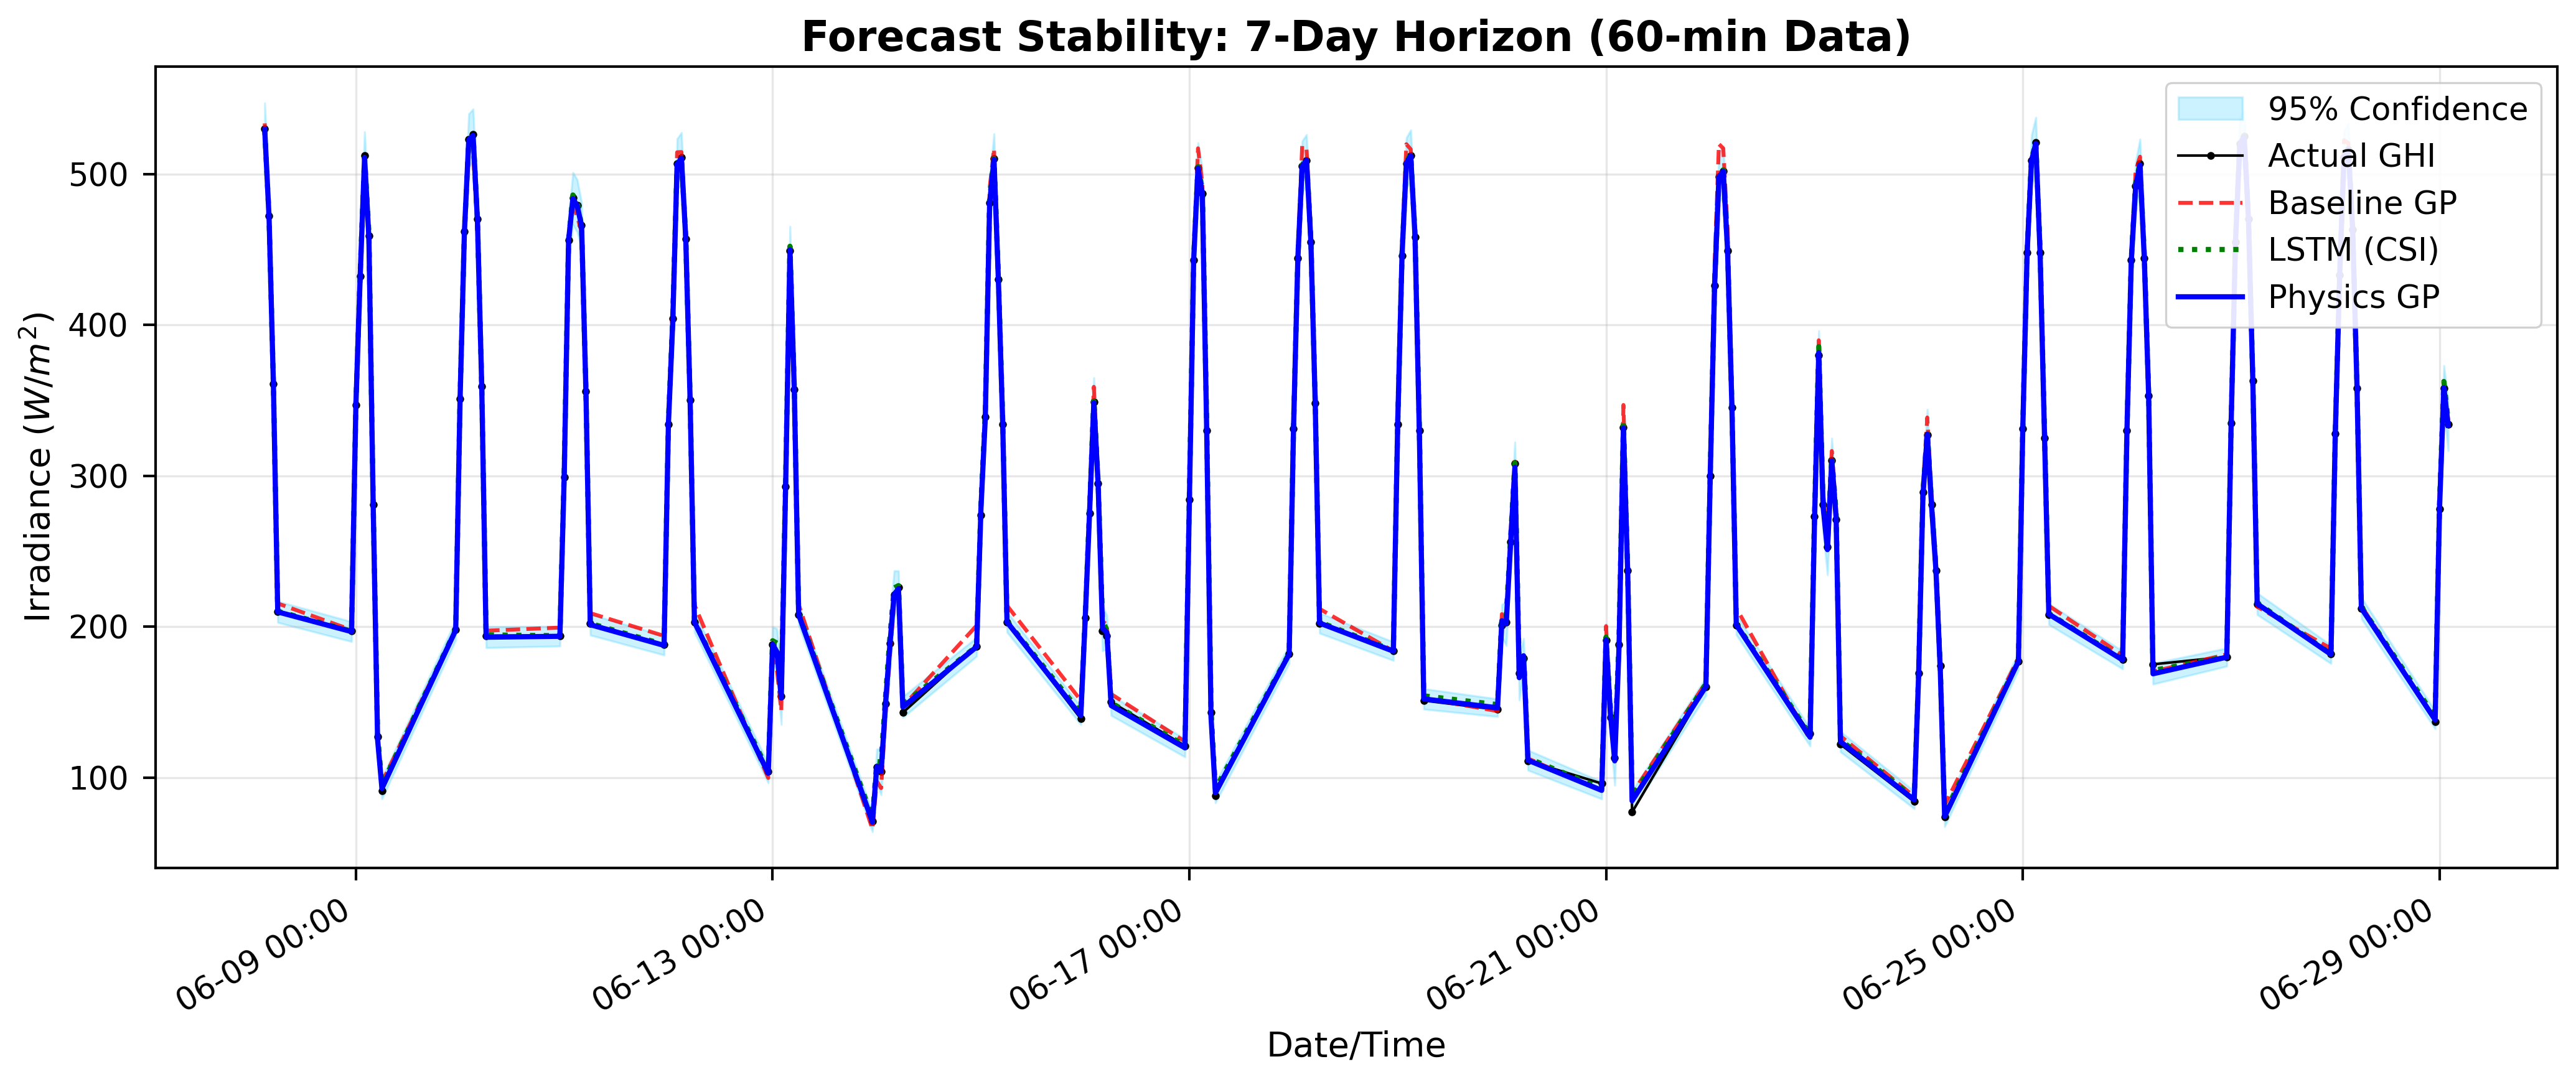

📸 Saved paper_plots/Figure_Forecast_Horizon_5min.png


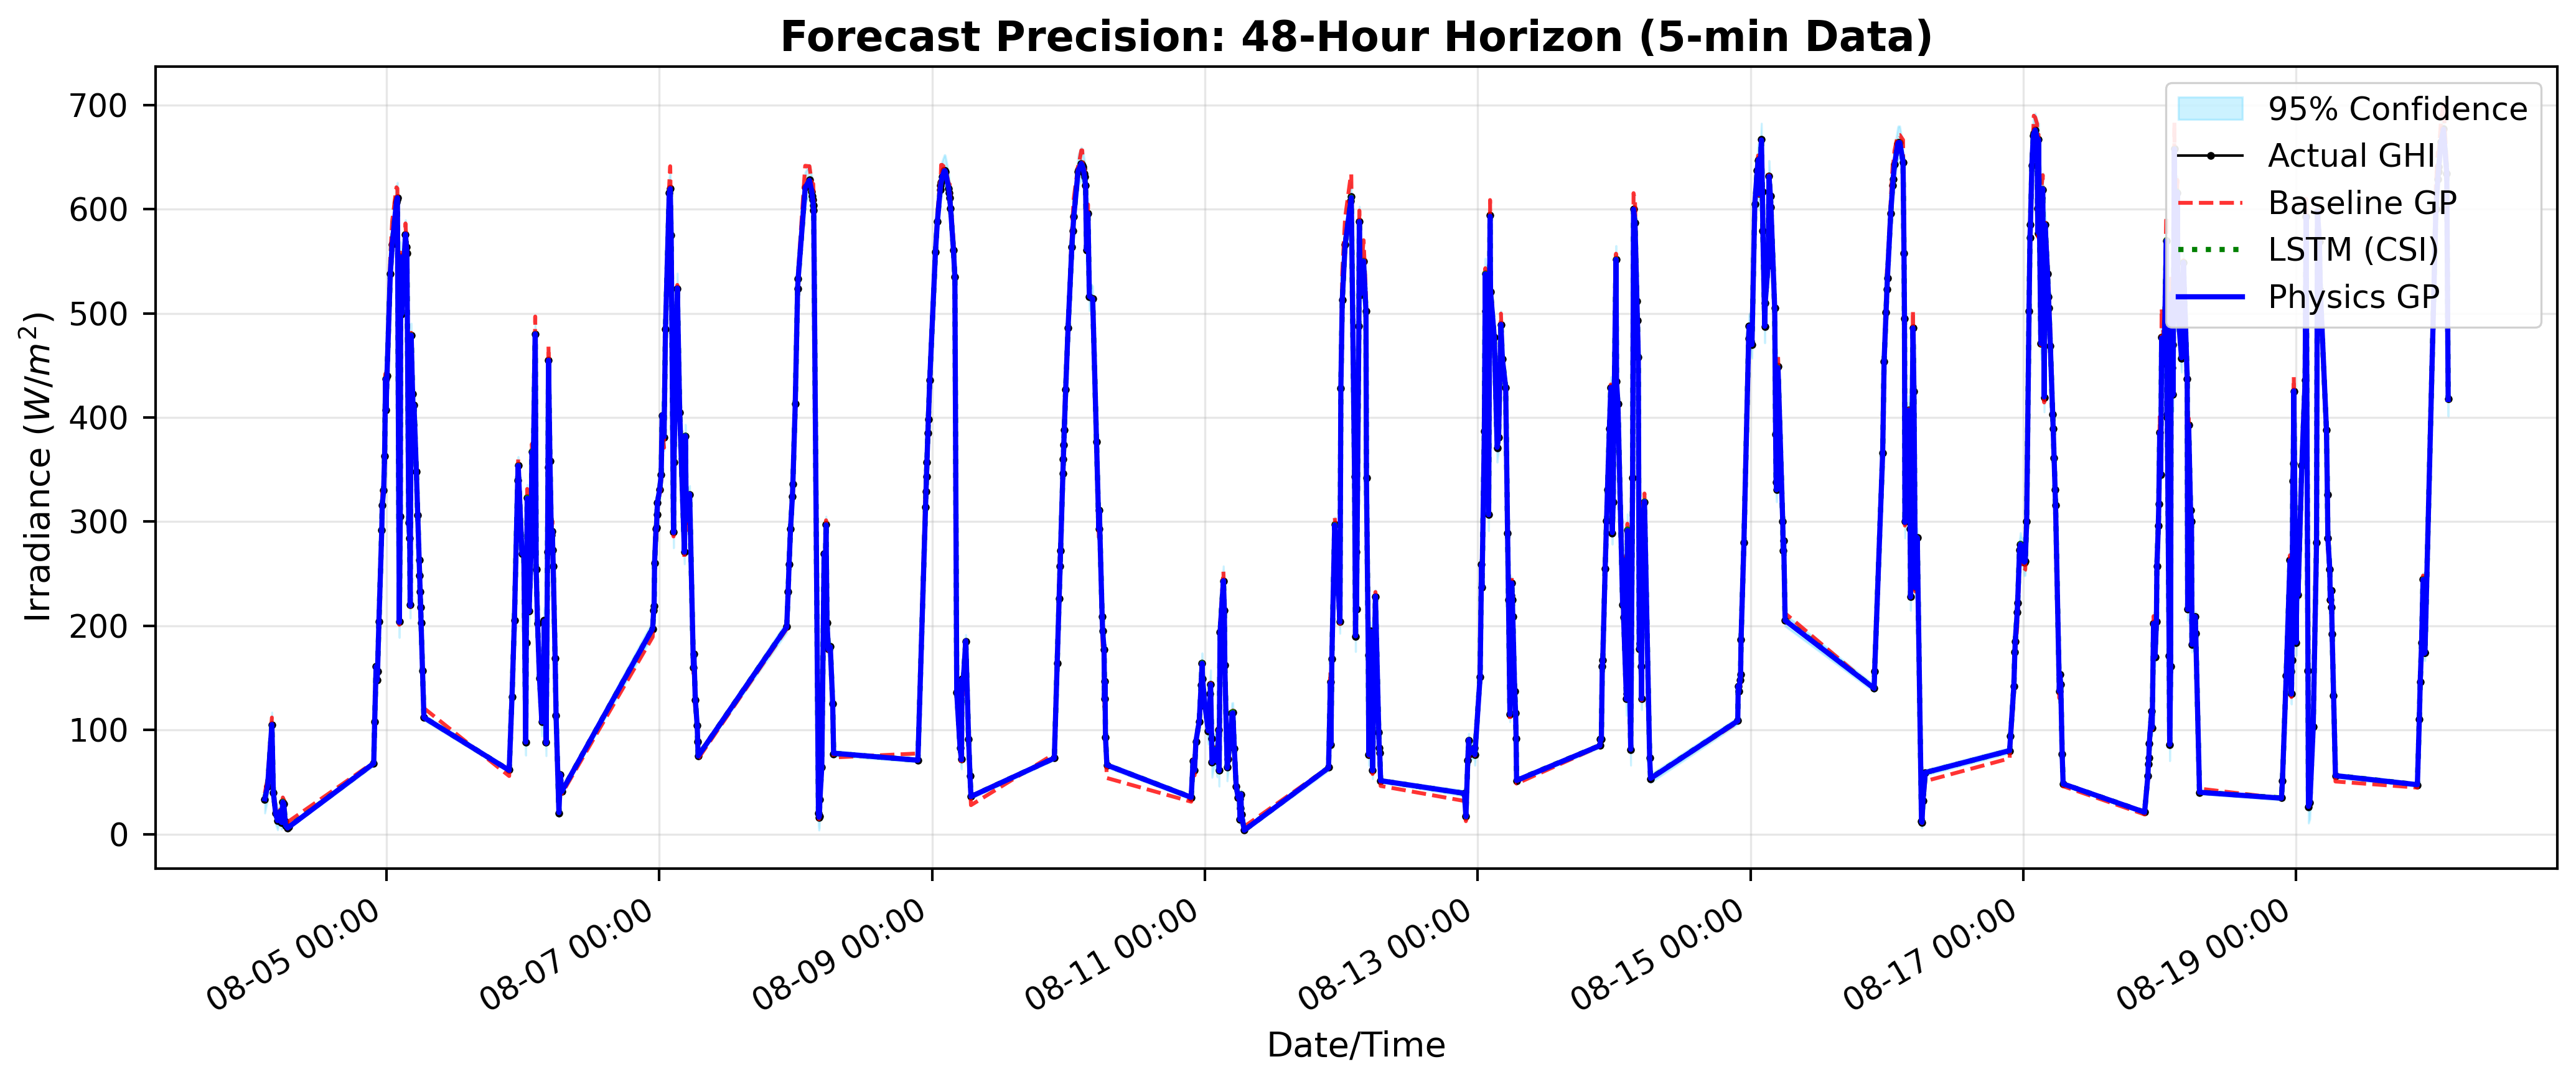

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# CONFIGURATION
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.4)

# LOAD DATA
try:
    df_5 = pd.read_csv("results/5min_all_predictions.csv", parse_dates=['Time'])
    df_60 = pd.read_csv("results/60min_all_predictions.csv", parse_dates=['Time'])
except FileNotFoundError:
    print("❌ Error: CSVs not found. Run save_predictions.py first."); exit()

# =============================================================================
# PLOTTING FUNCTION
# =============================================================================
def plot_forecast_horizon(df, title, filename, days=3, sample_start_idx=0):
    # Select a window
    # 60-min data: 24 points/day. 5-min data: 288 points/day.
    # We auto-detect frequency to set the window length
    dt = (df['Time'].iloc[1] - df['Time'].iloc[0]).total_seconds() / 60
    points_per_day = int(1440 / dt)
    
    start = sample_start_idx
    end = start + (points_per_day * days)
    
    # If index out of bounds, clip it
    if end > len(df): 
        start = 0
        end = points_per_day * days
        
    subset = df.iloc[start:end]

    plt.figure(figsize=(14, 6), dpi=300)
    
    # 1. Uncertainty (Physics Only - to keep it clean)
    # Check if CI columns exist
    if 'RBF_Lower_CI' in df.columns:
        plt.fill_between(subset['Time'], subset['RBF_Lower_CI'], subset['RBF_Upper_CI'], 
                         color='deepskyblue', alpha=0.2, label='95% Confidence')

    # 2. Actual Data
    plt.plot(subset['Time'], subset['Actual_GHI'], 'k-o', markersize=3, lw=1, label='Actual GHI')
    
    # 3. Baseline (Red Dashed)
    plt.plot(subset['Time'], subset['Pred_Baseline_Raw'], 'r--', lw=1.5, alpha=0.8, label='Baseline GP')
    
    # 4. LSTM (Green Dotted) - Optional, can comment out if too cluttered
    plt.plot(subset['Time'], subset['Pred_LSTM_CSI'], 'g:', lw=2, label='LSTM (CSI)')
    
    # 5. Physics GP (Blue Solid)
    plt.plot(subset['Time'], subset['Pred_Physics_RBF'], 'b-', lw=2, label='Physics GP')

    plt.title(title, fontsize=16, fontweight='bold')
    plt.ylabel("Irradiance ($W/m^2$)")
    plt.xlabel("Date/Time")
    plt.legend(loc='upper right', frameon=True, fancybox=True, framealpha=0.9)
    plt.grid(True, alpha=0.3)
    
    # Format Date Axis
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.gcf().autofmt_xdate()
    
    plt.tight_layout()
    plt.savefig(filename)
    print(f"📸 Saved {filename}")
    plt.show()

# =============================================================================
# GENERATE PLOTS
# =============================================================================

# 1. 60-Minute Plot (7 Days)
# We pick a start index that isn't just zeros (night). Let's skip the first 24 hours.
plot_forecast_horizon(df_60, 
                      "Forecast Stability: 7-Day Horizon (60-min Data)", 
                      "paper_plots/Figure_Forecast_Horizon_60min.png", 
                      days=7, 
                      sample_start_idx=48) # Start after 2 days

# 2. 5-Minute Plot (2 Days)
# 5-min data is dense, so 2 days is plenty of detail.
# We try to find the "Ramp Event" index again to ensure the plot is interesting
try:
    # Find volatile area again to center the plot
    df_5['Rolling_Std'] = df_5['Actual_GHI'].rolling(12).std()
    peak_idx = df_5['Rolling_Std'].idxmax()
    # Start 12 hours before the peak
    start_idx = max(0, peak_idx - (12 * 12)) 
except:
    start_idx = 288 # Fallback

plot_forecast_horizon(df_5, 
                      "Forecast Precision: 48-Hour Horizon (5-min Data)", 
                      "paper_plots/Figure_Forecast_Horizon_5min.png", 
                      days=2, 
                      sample_start_idx=start_idx)

In [6]:
# =============================================================================
# SCRIPT 4: EVALUATE RESULTS (Accuracy, Uncertainty & NLPD)
# =============================================================================
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# CONFIGURATION
BASELINE_COL = 'Pred_Baseline_Raw' 

# MODEL DEFINITIONS 
# Format: (Column Name, Display Name, Lower_CI_Col, Upper_CI_Col)
models = [
    ('Smart_Persistence', 'Smart Persistence', None, None),
    ('Pred_Baseline_Raw', 'Baseline GP (Raw)', 'Baseline_Lower_CI', 'Baseline_Upper_CI'),
    ('Pred_LSTM_Raw', 'LSTM (Raw)', None, None),
    ('Pred_LSTM_CSI', 'LSTM (CSI)', None, None),
    ('Pred_Physics_Matern', 'Physics GP (Matern)', None, None), # No saved CIs for this run
    ('Pred_Physics_RBF', 'Physics GP (RBF)', 'RBF_Lower_CI', 'RBF_Upper_CI') 
]

# LOAD DATA
try:
    df_60 = pd.read_csv("results/60min_all_predictions.csv")
    df_5 = pd.read_csv("results/5min_all_predictions.csv")
except FileNotFoundError:
    print("❌ Error: CSVs not found. Check 'results' folder.")
    exit()

def calculate_nlpd(y_true, y_pred, lower_ci, upper_ci):
    """
    Calculates Negative Log Predictive Density (NLPD).
    NLPD = 0.5 * log(2*pi*sigma^2) + ((y - mu)^2) / (2*sigma^2)
    """
    # 1. Recover Sigma (Standard Deviation) from 95% CI (1.96 std devs)
    # Width = Upper - Lower = 3.92 * Sigma
    sigma = (upper_ci - lower_ci) / 3.92
    
    # Safety: Avoid division by zero or log(0)
    sigma = np.clip(sigma, 1e-6, None) 
    var = sigma ** 2
    
    # 2. Compute NLPD term by term
    term1 = 0.5 * np.log(2 * np.pi * var)
    term2 = ((y_true - y_pred) ** 2) / (2 * var)
    nlpd = term1 + term2
    
    return np.mean(nlpd)

def generate_latex_table(df, dataset_name):
    print(f"\n{'='*60}")
    print(f"📊 GENERATING TABLE FOR: {dataset_name}")
    print(f"{'='*60}")
    
    # 1. ESTABLISH BASELINES
    common_mask = df[BASELINE_COL].notna() & df['Actual_GHI'].notna()
    
    # Baseline Metrics
    base_rmse = np.sqrt(mean_squared_error(df.loc[common_mask, 'Actual_GHI'], df.loc[common_mask, BASELINE_COL]))
    
    # Calculate Baseline NLPD
    base_nlpd = calculate_nlpd(
        df.loc[common_mask, 'Actual_GHI'],
        df.loc[common_mask, BASELINE_COL],
        df.loc[common_mask, 'Baseline_Lower_CI'],
        df.loc[common_mask, 'Baseline_Upper_CI']
    )

    results = []
    
    for col, name, low_ci, high_ci in models:
        # Filter NaNs
        mask = df[col].notna() & df['Actual_GHI'].notna()
        y_true = df.loc[mask, 'Actual_GHI']
        y_pred = df.loc[mask, col]
        
        # A. STANDARD ACCURACY
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        imp_rmse = (1 - (rmse / base_rmse)) * 100
        
        # B. PROBABILISTIC METRICS (NLPD)
        if low_ci and high_ci and (low_ci in df.columns):
            # Calculate NLPD
            nlpd_val = calculate_nlpd(
                y_true, y_pred, 
                df.loc[mask, low_ci], 
                df.loc[mask, high_ci]
            )
            nlpd_str = f"{nlpd_val:.2f}"
            
            # Improvement in NLPD (Lower is better, so strictly: Base - Model)
            # A positive difference means the model has lower (better) NLPD than baseline
            imp_nlpd = base_nlpd - nlpd_val
            imp_nlpd_str = f"{imp_nlpd:.2f}" 
        else:
            nlpd_str = "-"
            imp_nlpd_str = "-"

        results.append({
            "Model": name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "Imp. RMSE (%)": imp_rmse,
            "NLPD": nlpd_str,
            "Imp. NLPD": imp_nlpd_str
        })
        
    # Create DataFrame & Sort
    res_df = pd.DataFrame(results)
    res_df = res_df.sort_values("RMSE")
    
    # 2. PRINT
    print(res_df.to_string(index=False))
    
   

# EXECUTE
generate_latex_table(df_60, "60-Minute Benchmark")
generate_latex_table(df_5, "5-Minute Benchmark")


📊 GENERATING TABLE FOR: 60-Minute Benchmark
              Model      RMSE       MAE       R2  Imp. RMSE (%) NLPD Imp. NLPD
   Physics GP (RBF)  2.625083  1.646100 0.999757      64.086734 3.04      0.72
Physics GP (Matern)  2.740843  1.938634 0.999735      62.503046    -         -
         LSTM (CSI)  3.369308  2.380478 0.999599      53.905132    -         -
  Baseline GP (Raw)  7.309508  5.846874 0.998114       0.000000 3.77      0.00
         LSTM (Raw) 11.747958  9.716542 0.995129     -60.721599    -         -
  Smart Persistence 62.710153 37.308281 0.861215    -757.925764    -         -

📊 GENERATING TABLE FOR: 5-Minute Benchmark
              Model      RMSE       MAE       R2  Imp. RMSE (%) NLPD Imp. NLPD
   Physics GP (RBF)  0.313513  0.226630 0.999997      96.166484 2.37      3.19
         LSTM (CSI)  0.589176  0.419956 0.999989      92.795771    -         -
Physics GP (Matern)  0.979687  0.827721 0.999970      88.020747    -         -
  Baseline GP (Raw)  8.178199  6.338343 0.